# Seaquest DQN — Exp 8: exp8_mixed_mid
**1M steps from scratch** | CnnPolicy | ALE/Seaquest-v5

In [1]:
import subprocess, sys

# Reinstall PyTorch with correct CUDA version for this Kaggle GPU
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q',
    'torch', 'torchvision', '--index-url', 'https://download.pytorch.org/whl/cu121'])

for pkg in ['ale-py', 'gymnasium[atari]', 'stable-baselines3', 'opencv-python']:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])
print('All packages installed.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.0/188.0 kB 6.0 MB/s eta 0:00:00
All packages installed.


In [2]:
import os, csv, gc
import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym
import ale_py
import torch
from stable_baselines3 import DQN
from stable_baselines3.common.atari_wrappers import AtariWrapper
from stable_baselines3.common.vec_env import DummyVecEnv, VecFrameStack
from stable_baselines3.common.callbacks import EvalCallback
print('CUDA available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))

2026-03-22 12:21:50.969855: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774182111.206834      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774182111.273927      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774182111.786123      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774182111.786165      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774182111.786168      55 computation_placer.cc:177] computation placer alr

CUDA available: True
GPU: Tesla T4


In [3]:
EXP_ID = 8
EXP_NAME = 'exp8_mixed_mid'
LR = 0.0004
GAMMA = 0.95
BATCH_SIZE = 64
EPS_START = 0.9
EPS_END = 0.02
EPS_FRAC = 0.10
NOTES = 'Mixed mid — combined moderate changes'

ENV_ID = 'ALE/Seaquest-v5'
TOTAL_TIMESTEPS = 1_000_000
BUFFER_SIZE = 50_000
LEARNING_STARTS = 10_000
TARGET_UPDATE = 1_000
N_STACK = 4
OUTPUT_DIR = f'/kaggle/working/kerie/runs/{EXP_NAME}'

print(f'Exp {EXP_ID}: {EXP_NAME}')
print(f'Steps: {TOTAL_TIMESTEPS:,}')
print(f'lr={LR} gamma={GAMMA} batch={BATCH_SIZE}')
print(f'eps: {EPS_START} -> {EPS_END} over {EPS_FRAC} of training')

Exp 8: exp8_mixed_mid
Steps: 1,000,000
lr=0.0004 gamma=0.95 batch=64
eps: 0.9 -> 0.02 over 0.1 of training


In [4]:
def make_env(render_mode=None):
    def _init():
        env = gym.make(ENV_ID, render_mode=render_mode)
        env = AtariWrapper(env)
        return env
    vec_env = DummyVecEnv([_init])
    vec_env = VecFrameStack(vec_env, n_stack=N_STACK)
    return vec_env

log_dir = os.path.join(OUTPUT_DIR, 'tensorboard')
eval_dir = os.path.join(OUTPUT_DIR, 'eval')
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(log_dir, exist_ok=True)
os.makedirs(eval_dir, exist_ok=True)

train_env = make_env()
eval_env = make_env()

# optimize_memory_usage: avoids storing next_state twice in replay buffer (~50% less RAM)
# handle_timeout_termination=False required when optimize_memory_usage=True
# Safe for Atari — AtariWrapper handles episode boundaries via life-loss detection
model = DQN(
    policy='CnnPolicy',
    env=train_env,
    learning_rate=LR,
    gamma=GAMMA,
    batch_size=BATCH_SIZE,
    exploration_initial_eps=EPS_START,
    exploration_final_eps=EPS_END,
    exploration_fraction=EPS_FRAC,
    buffer_size=BUFFER_SIZE,
    learning_starts=LEARNING_STARTS,
    target_update_interval=TARGET_UPDATE,
    tensorboard_log=log_dir,
    verbose=1,
    optimize_memory_usage=True,
    replay_buffer_kwargs={'handle_timeout_termination': False},
)

eval_callback = EvalCallback(
    eval_env,
    best_model_save_path=eval_dir,
    log_path=eval_dir,
    eval_freq=25_000,
    n_eval_episodes=5,
    deterministic=True,
    render=False,
)

model.learn(
    total_timesteps=TOTAL_TIMESTEPS,
    callback=eval_callback,
    tb_log_name=EXP_NAME,
    reset_num_timesteps=True,
)

model.save(os.path.join(OUTPUT_DIR, 'dqn_model'))
print(f'\nModel saved -> {OUTPUT_DIR}/dqn_model.zip')

train_env.close()
eval_env.close()
del model
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

A.L.E: Arcade Learning Environment (version 0.11.2+ecc1138)
[Powered by Stella]


Using cuda device
Wrapping the env in a VecTransposeImage.
Logging to /kaggle/working/kerie/runs/exp8_mixed_mid/tensorboard/exp8_mixed_mid_1


/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/callbacks.py:418: UserWarning: Training and eval env are not of the same type<stable_baselines3.common.vec_env.vec_transpose.VecTransposeImage object at 0x7e0b01af6bd0> != <stable_baselines3.common.vec_env.vec_frame_stack.VecFrameStack object at 0x7e0b01501550>
  warnings.warn("Training and eval env are not of the same type" f"{self.training_env} != {self.eval_env}")


----------------------------------
| rollout/            |          |
|    exploration_rate | 0.898    |
| time/               |          |
|    episodes         | 4        |
|    fps              | 332      |
|    time_elapsed     | 0        |
|    total_timesteps  | 234      |
----------------------------------
----------------------------------
| rollout/            |          |
|    exploration_rate | 0.897    |
| time/               |          |
|    episodes         | 8        |
|    fps              | 327      |
|    time_elapsed     | 0        |
|    total_timesteps  | 320      |
----------------------------------
----------------------------------
| rollout/            |          |
|    exploration_rate | 0.896    |
| time/               |          |
|    episodes         | 12       |
|    fps              | 332      |
|    time_elapsed     | 1        |
|    total_timesteps  | 484      |
----------------------------------
----------------------------------
| rollout/          

/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/evaluation.py:70: UserWarning: Evaluation environment is not wrapped with a ``Monitor`` wrapper. This may result in reporting modified episode lengths and rewards, if other wrappers happen to modify these. Consider wrapping environment first with ``Monitor`` wrapper.
  warnings.warn(


Eval num_timesteps=25000, episode_reward=2.60 +/- 1.62
Episode length: 52.20 +/- 27.65
----------------------------------
| eval/               |          |
|    mean_ep_length   | 52.2     |
|    mean_reward      | 2.6      |
| rollout/            |          |
|    exploration_rate | 0.68     |
| time/               |          |
|    total_timesteps  | 25000    |
| train/              |          |
|    learning_rate    | 0.0004   |
|    loss             | 0.0601   |
|    n_updates        | 3749     |
----------------------------------
New best mean reward!
----------------------------------
| rollout/            |          |
|    exploration_rate | 0.679    |
| time/               |          |
|    episodes         | 904      |
|    fps              | 232      |
|    time_elapsed     | 107      |
|    total_timesteps  | 25113    |
| train/              |          |
|    learning_rate    | 0.0004   |
|    loss             | 0.0933   |
|    n_updates        | 3778     |
----------------

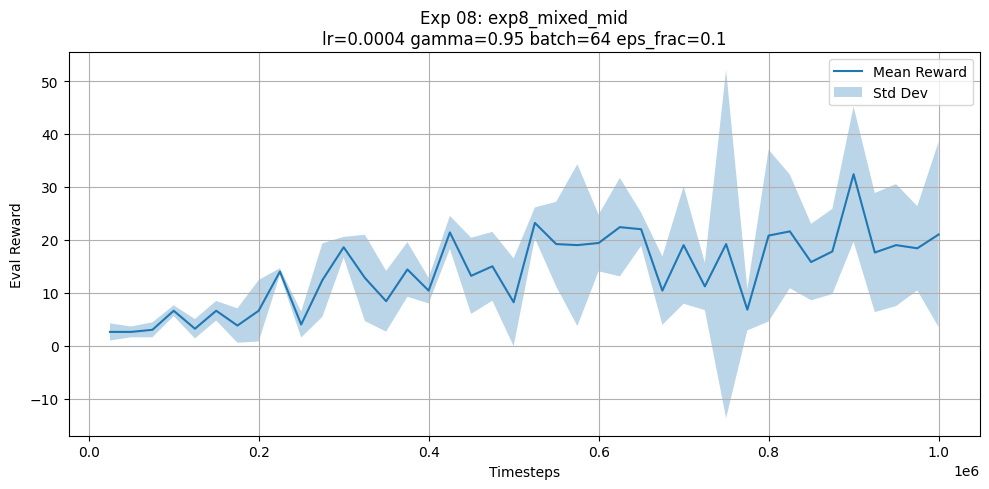

Best reward: 32.4
Final reward: 21.0

Download outputs from the Output tab ->


In [5]:
eval_npz = os.path.join(eval_dir, 'evaluations.npz')
if os.path.isfile(eval_npz):
    data = np.load(eval_npz)
    timesteps = data['timesteps']
    mean_rewards = data['results'].mean(axis=1)
    std_rewards = data['results'].std(axis=1)

    plt.figure(figsize=(10, 5))
    plt.plot(timesteps, mean_rewards, label='Mean Reward')
    plt.fill_between(timesteps, mean_rewards - std_rewards, mean_rewards + std_rewards, alpha=0.3, label='Std Dev')
    plt.xlabel('Timesteps')
    plt.ylabel('Eval Reward')
    plt.title(f'Exp {EXP_ID:02d}: {EXP_NAME}\nlr={LR} gamma={GAMMA} batch={BATCH_SIZE} eps_frac={EPS_FRAC}')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'reward_plot.png'), dpi=150)
    plt.show()

    csv_path = os.path.join(OUTPUT_DIR, 'results.csv')
    with open(csv_path, 'w', newline='') as f:
        writer = csv.writer(f)
        writer.writerow(['timestep', 'mean_reward', 'std_reward'])
        for t, m, s in zip(timesteps, mean_rewards, std_rewards):
            writer.writerow([int(t), f'{m:.2f}', f'{s:.2f}'])

    print(f'Best reward: {mean_rewards.max():.1f}')
    print(f'Final reward: {mean_rewards[-1]:.1f}')
    print(f'\nDownload outputs from the Output tab ->')